# Classifier Domain-Aug Experiment

Transparent GPU notebook for ore image classification experiments. Outputs are saved inside this notebook directory.

In [1]:
from pathlib import Path
import csv
import json
import shutil
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image, ImageDraw, ImageOps
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_recall_fscore_support, roc_auc_score
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

ROOT = Path.cwd()

def find_project_root():
    markers = [Path('configs') / 'classifier' / 'nornikel_classifier_domain_aug_effnet_b0.json', Path('models') / 'classifiers.py']
    candidates = [ROOT, *ROOT.parents, Path(r'D:\Nornikel-2026-Shlif-Case')]
    for candidate in candidates:
        if all((candidate / marker).exists() for marker in markers):
            return candidate
    raise FileNotFoundError('Could not find project root. Set PROJECT_ROOT manually.')

PROJECT_ROOT = find_project_root()
NOTEBOOK_DIR = PROJECT_ROOT / 'notebooks' / 'classifier_experiments'
OUT = NOTEBOOK_DIR / 'outputs'
RUNS_DIR = OUT / 'runs'
PLOTS_DIR = OUT / 'plots'
EVAL_DIR = OUT / 'evaluation'
for path in [RUNS_DIR, PLOTS_DIR, EVAL_DIR]:
    path.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

def project_path(value):
    path = Path(value)
    return str(path if path.is_absolute() else PROJECT_ROOT / path)

print('PROJECT_ROOT =', PROJECT_ROOT)
print('OUT =', OUT)
print('torch =', torch.__version__, 'cuda =', torch.cuda.is_available())

PROJECT_ROOT = D:\Nornikel-2026-Shlif-Case
OUT = D:\Nornikel-2026-Shlif-Case\notebooks\classifier_experiments\outputs
torch = 2.12.1+cu126 cuda = True


## 1. Experiment config

In [2]:
from hydra.json_config import JsonConfig

EXPERIMENT_NAME = 'effnet_b0_domain_aug'
CONFIG_PATH = PROJECT_ROOT / 'configs' / 'classifier' / 'nornikel_classifier_domain_aug_effnet_b0.json'

cfg = JsonConfig.load(CONFIG_PATH).to_dict()
cfg['manifest_csv'] = project_path(cfg['manifest_csv'])
cfg['run_dir'] = str(RUNS_DIR / EXPERIMENT_NAME)
cfg['mlflow']['enabled'] = False

# Quick debug knobs:
# cfg['trainer']['epochs'] = 2
# cfg['data']['batch_size'] = 4

Path(cfg['run_dir']).mkdir(parents=True, exist_ok=True)
(Path(cfg['run_dir']) / 'resolved_config.json').write_text(json.dumps(cfg, ensure_ascii=False, indent=2), encoding='utf-8')
cfg

{'seed': 42,
 'device': 'auto',
 'manifest_csv': 'D:\\Nornikel-2026-Shlif-Case\\artifacts\\manifests\\nornikel_manifest.csv',
 'run_dir': 'D:\\Nornikel-2026-Shlif-Case\\notebooks\\classifier_experiments\\outputs\\runs\\effnet_b0_domain_aug',
 'mlflow': {'enabled': False,
  'tracking_uri': 'sqlite:///artifacts/mlflow.db',
  'experiment': 'nornikel_ore_classifier',
  'run_name': 'efficientnet_b0_domain_aug'},
 'include_sources': ['classification'],
 'exclude_conflicts': True,
 'exclude_duplicate_leaks': True,
 'classes': ['ordinary', 'thin', 'talc'],
 'data': {'image_size': 384,
  'batch_size': 8,
  'num_workers': 0,
  'use_weighted_sampler': True},
 'augmentation': {'resize_mode': 'random_resized_crop',
  'crop_scale': [0.76, 1.0],
  'crop_ratio': [0.86, 1.16],
  'hflip_p': 0.5,
  'vflip_p': 0.25,
  'brightness': 0.22,
  'contrast': 0.26,
  'saturation': 0.22,
  'hue': 0.025,
  'gamma': 0.15,
  'gray_domain_p': 0.45,
  'gray_saturation_min': 0.04,
  'gray_saturation_max': 0.42,
  'gray_

## 2. Dataset sanity check

In [3]:
manifest = pd.read_csv(cfg['manifest_csv'])
cls_df = manifest[(manifest['source'].isin(cfg['include_sources'])) & (manifest['label'].isin(cfg['classes'])) & (~manifest['label_conflict'].astype(str).str.lower().eq('true'))]
display(pd.crosstab(cls_df['subset'], cls_df['label']))
display(cls_df.groupby(['subset', 'label'])[['width', 'height']].median())

label,ordinary,talc,thin
subset,,,
train,382,73,324
val,93,11,80


width  height
subset label                   
train  ordinary  2272.0  1704.0
       talc      4160.0  2768.0
       thin      2272.0  1704.0
val    ordinary  2272.0  1704.0
       talc      4160.0  2768.0
       thin      2272.0  1704.0

## 3. Train

In [4]:
from trainers.classification_trainer import ClassificationTrainer

trainer = ClassificationTrainer(cfg)
summary = trainer.fit()
if summary.get('epochs', cfg['trainer']['epochs']) < cfg['trainer']['epochs']:
    print(
        f"Early stopping: trained {summary['epochs']} / {cfg['trainer']['epochs']} epochs. "
        f"Best checkpoint is saved at {Path(cfg['run_dir']) / 'best.pt'}"
    )
summary

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\Computer/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:06<00:00, 3.33MB/s]
D:\Nornikel-2026-Shlif-Case\trainers\classification_trainer.py:66: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(enabled=cfg["trainer"].get("amp", True) and self.device.type == "cuda")


epochs:   0%|          | 0/14 [00:00<?, ?epoch/s]

train epoch 1:   0%|          | 0/98 [00:00<?, ?batch/s]

D:\Nornikel-2026-Shlif-Case\trainers\classification_trainer.py:122: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=self.scaler.is_enabled()):


...

train epoch 10:   0%|          | 0/98 [00:00<?, ?batch/s]

D:\Nornikel-2026-Shlif-Case\trainers\classification_trainer.py:122: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=self.scaler.is_enabled()):


val epoch 10:   0%|          | 0/23 [00:00<?, ?batch/s]

D:\Nornikel-2026-Shlif-Case\trainers\classification_trainer.py:122: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=self.scaler.is_enabled()):


{'best_val_macro_f1': 0.9196432928316987, 'epochs': 10}

## 4. Training curves

,epoch,train_macro_precision,train_macro_recall,train_macro_f1,train_macro_dice,train_macro_auc,train_loss,train_accuracy,val_macro_precision,val_macro_recall,val_macro_f1,val_macro_dice,val_macro_auc,val_loss,val_accuracy
5,6,0.901108,0.899863,0.900303,0.900303,0.982605,0.402529,0.901155,0.823299,0.894025,0.848356,0.848356,0.975121,0.461858,0.891304
6,7,0.908452,0.909372,0.908739,0.908739,0.983205,0.386138,0.908858,0.846288,0.910692,0.871947,0.871947,0.965077,0.427837,0.913043
7,8,0.923766,0.923955,0.923830,0.923830,0.983104,0.382000,0.924262,0.802743,0.890351,0.834216,0.834216,0.965735,0.512771,0.880435
8,9,0.927278,0.927389,0.927271,0.927271,0.985406,0.368142,0.926829,0.881933,0.904688,0.892635,0.892635,0.969826,0.447386,0.902174
9,10,0.935554,0.936202,0.935767,0.935767,0.988311,0.350255,0.935815,0.881933,0.904688,0.892635,0.892635,0.969226,0.434061,0.902174


WindowsPath('D:/Nornikel-2026-Shlif-Case/notebooks/classifier_experiments/outputs/plots/effnet_b0_domain_aug_training_curves.png')

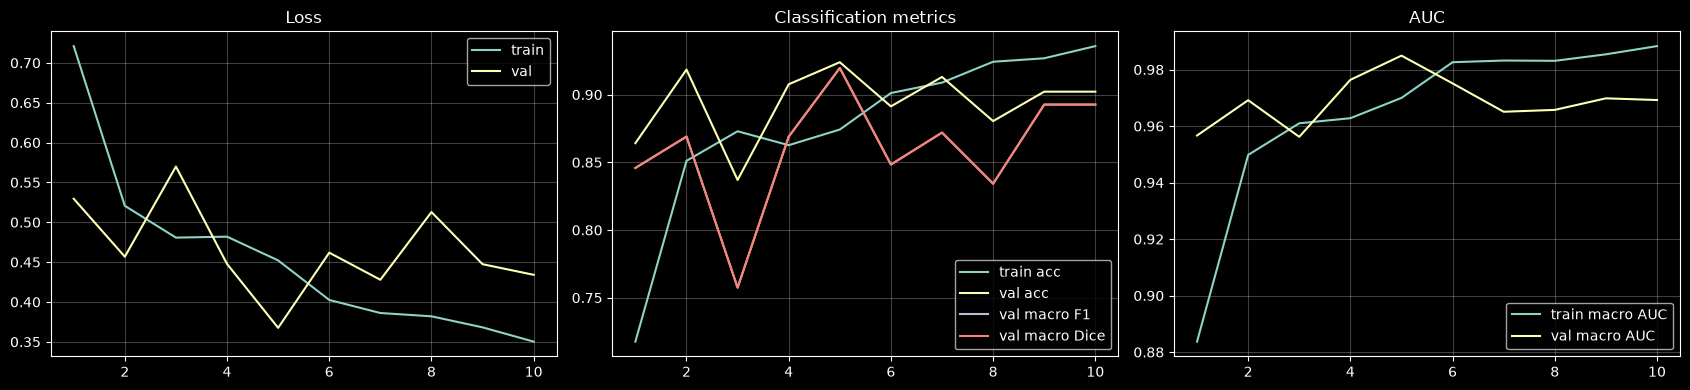

In [5]:
run_dir = Path(cfg['run_dir'])
history = pd.read_csv(run_dir / 'history.csv')
display(history.tail())

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
axes[0].plot(history['epoch'], history['train_loss'], label='train')
axes[0].plot(history['epoch'], history['val_loss'], label='val')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history['epoch'], history['train_accuracy'], label='train acc')
axes[1].plot(history['epoch'], history['val_accuracy'], label='val acc')
axes[1].plot(history['epoch'], history['val_macro_f1'], label='val macro F1')
axes[1].plot(history['epoch'], history['val_macro_dice'], label='val macro Dice')
axes[1].set_title('Classification metrics')
axes[1].legend()

axes[2].plot(history['epoch'], history['train_macro_auc'], label='train macro AUC')
axes[2].plot(history['epoch'], history['val_macro_auc'], label='val macro AUC')
axes[2].set_title('AUC')
axes[2].legend()

for ax in axes:
    ax.grid(alpha=0.25)
fig.tight_layout()
plot_path = PLOTS_DIR / f'{EXPERIMENT_NAME}_training_curves.png'
fig.savefig(plot_path, dpi=160)
plot_path

## 5. Best validation metrics from trainer

In [6]:
best_metrics = json.loads((run_dir / 'best_metrics.json').read_text(encoding='utf-8'))
best_per_class = pd.read_csv(run_dir / 'best_per_class_metrics.csv')
display(pd.DataFrame([best_metrics]).drop(columns=['per_class'], errors='ignore').T.rename(columns={0: 'best_val'}))
display(best_per_class)

,best_val
macro_precision,0.919264
macro_recall,0.920190
macro_f1,0.919643
macro_dice,0.919643
macro_auc,0.984941
loss,0.367539
accuracy,0.923913


,class,precision,recall,f1,dice,auc,support
0,ordinary,0.934066,0.913978,0.923913,0.923913,0.979440,93
1,thin,0.914634,0.937500,0.925926,0.925926,0.986418,80
2,talc,0.909091,0.909091,0.909091,0.909091,0.988965,11


## 6. Full evaluation: train and val

Per-class metrics include precision, recall, F1, Dice and one-vs-rest AUC. Dice equals F1 for single-label classification, but is kept explicit for reporting.

In [7]:
from data.datasets import OreClassificationDataset
from models.classifiers import ClassifierFactory

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
checkpoint = torch.load(run_dir / 'best.pt', map_location=DEVICE)
classes = checkpoint.get('classes', cfg['classes'])
model = ClassifierFactory.create(checkpoint['config']['model'], len(classes)).to(DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

def evaluate_subset(subset):
    dataset = OreClassificationDataset(
        manifest_csv=cfg['manifest_csv'],
        classes=classes,
        subset=subset,
        image_size=cfg['data']['image_size'],
        include_sources=cfg.get('include_sources'),
        exclude_conflicts=cfg.get('exclude_conflicts', True),
        augmentation_cfg={},
    )
    loader = DataLoader(dataset, batch_size=cfg['data']['batch_size'], shuffle=False, num_workers=cfg['data'].get('num_workers', 0))
    y_true, y_pred, y_prob, rows = [], [], [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc=f'eval {subset}', unit='batch'):
            logits = model(batch['image'].to(DEVICE))
            probs = torch.softmax(logits, dim=1).detach().cpu().numpy()
            preds = probs.argmax(axis=1)
            labels = batch['label'].numpy()
            y_true.extend(labels.tolist())
            y_pred.extend(preds.tolist())
            y_prob.extend(probs.tolist())
            for path, true_idx, pred_idx, prob in zip(batch['path'], labels.tolist(), preds.tolist(), probs.tolist()):
                row = {'subset': subset, 'path': path, 'true_label': classes[true_idx], 'pred_label': classes[pred_idx], 'confidence': float(max(prob)), 'is_error': true_idx != pred_idx}
                for cls, p in zip(classes, prob):
                    row[f'prob_{cls}'] = float(p)
                rows.append(row)
    probs = np.asarray(y_prob, dtype=np.float32)
    true = np.asarray(y_true)
    pred = np.asarray(y_pred)
    precision, recall, f1, support = precision_recall_fscore_support(true, pred, labels=list(range(len(classes))), zero_division=0)
    per_class = []
    auc_values = []
    for idx, cls in enumerate(classes):
        binary = (true == idx).astype(np.uint8)
        auc = float('nan') if len(np.unique(binary)) < 2 else float(roc_auc_score(binary, probs[:, idx]))
        if not np.isnan(auc):
            auc_values.append(auc)
        per_class.append({'class': cls, 'precision': precision[idx], 'recall': recall[idx], 'f1': f1[idx], 'dice': f1[idx], 'auc': auc, 'support': int(support[idx])})
    macro = {
        'subset': subset,
        'accuracy': accuracy_score(true, pred),
        'macro_precision': float(np.mean(precision)),
        'macro_recall': float(np.mean(recall)),
        'macro_f1': float(np.mean(f1)),
        'macro_dice': float(np.mean(f1)),
        'macro_auc': float(np.mean(auc_values)) if auc_values else float('nan'),
    }
    subset_dir = EVAL_DIR / EXPERIMENT_NAME / subset
    subset_dir.mkdir(parents=True, exist_ok=True)
    pd.DataFrame(rows).to_csv(subset_dir / 'predictions.csv', index=False)
    pd.DataFrame(per_class).to_csv(subset_dir / 'per_class_metrics.csv', index=False)
    pd.DataFrame([macro]).to_csv(subset_dir / 'macro_metrics.csv', index=False)
    cm = confusion_matrix(true, pred, labels=list(range(len(classes))))
    pd.DataFrame(cm, index=classes, columns=classes).to_csv(subset_dir / 'confusion.csv')
    save_error_gallery(rows, subset_dir / 'error_examples.jpg')
    return macro, pd.DataFrame(per_class), pd.DataFrame(cm, index=classes, columns=classes)

def save_error_gallery(rows, output_path, max_items=30, thumb=180):
    errors = [row for row in rows if row['is_error']]
    errors = sorted(errors, key=lambda row: row['confidence'], reverse=True)[:max_items]
    if not errors:
        return
    cols = 5
    sheet_rows = int(np.ceil(len(errors) / cols))
    sheet = Image.new('RGB', (cols * thumb, sheet_rows * (thumb + 50)), (24, 28, 32))
    draw = ImageDraw.Draw(sheet)
    for idx, row in enumerate(errors):
        x = (idx % cols) * thumb
        y = (idx // cols) * (thumb + 50)
        with Image.open(row['path']) as img:
            image = ImageOps.exif_transpose(img).convert('RGB')
            image.thumbnail((thumb, thumb))
            sheet.paste(image, (x, y))
        draw.text((x + 3, y + thumb + 4), f"T:{row['true_label']} P:{row['pred_label']}", fill=(235, 238, 242))
        draw.text((x + 3, y + thumb + 24), f"conf={row['confidence']:.2f}", fill=(235, 238, 242))
    sheet.save(output_path, quality=92)

macro_rows = []
for subset in ['train', 'val']:
    macro, per_class, cm = evaluate_subset(subset)
    macro_rows.append(macro)
    print('\n', subset.upper(), 'macro')
    display(pd.DataFrame([macro]))
    print(subset.upper(), 'per class')
    display(per_class)
    print(subset.upper(), 'confusion')
    display(cm)

pd.DataFrame(macro_rows).to_csv(EVAL_DIR / EXPERIMENT_NAME / 'macro_metrics.csv', index=False)

eval train:   0%|          | 0/98 [00:00<?, ?batch/s]


 TRAIN macro


,subset,accuracy,macro_precision,macro_recall,macro_f1,macro_dice,macro_auc
0,train,0.953787,0.966005,0.932688,0.947967,0.947967,0.993985


TRAIN per class


,class,precision,recall,f1,dice,auc,support
0,ordinary,0.956298,0.973822,0.964981,0.964981,0.994270,382
1,thin,0.941718,0.947531,0.944615,0.944615,0.988170,324
2,talc,1.000000,0.876712,0.934307,0.934307,0.999515,73


...

,subset,accuracy,macro_precision,macro_recall,macro_f1,macro_dice,macro_auc
0,val,0.923913,0.919264,0.92019,0.919643,0.919643,0.984942


VAL per class


,class,precision,recall,f1,dice,auc,support
0,ordinary,0.934066,0.913978,0.923913,0.923913,0.979322,93
1,thin,0.914634,0.937500,0.925926,0.925926,0.986538,80
2,talc,0.909091,0.909091,0.909091,0.909091,0.988965,11


VAL confusion


,ordinary,thin,talc
ordinary,85,7,1
thin,5,75,0
talc,1,0,10


## 7. Optional: 5-fold stratified cross-validation

Set `RUN_5FOLD = True` to train 5 models. Each fold prints best validation macro metrics, per-class metrics and confusion matrix.

In [10]:
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
from data.manifest import write_manifest
import importlib
import data.datasets as datasets_module
import trainers.classification_trainer as classification_trainer_module

# Jupyter keeps old imports alive; reload so fold manifests use the fixed project-root resolver.
importlib.reload(datasets_module)
classification_trainer_module = importlib.reload(classification_trainer_module)
ClassificationTrainer = classification_trainer_module.ClassificationTrainer

RUN_5FOLD = True
N_FOLDS = 5
CV_EPOCHS = cfg['trainer']['epochs']
CV_PATIENCE = cfg['trainer']['early_stopping_patience']

def make_cv_manifest(base_manifest_csv, output_csv, fold_idx, n_folds=5, seed=42):
    rows = list(csv.DictReader(open(base_manifest_csv, newline='', encoding='utf-8')))
    eligible_idx = [
        i for i, row in enumerate(rows)
        if row.get('source') in cfg.get('include_sources', [])
        and row.get('label') in cfg['classes']
        and str(row.get('label_conflict', '')).lower() != 'true'
    ]
    labels = np.array([rows[i]['label'] for i in eligible_idx])
    groups = np.array([rows[i].get('content_hash') or rows[i].get('rel_path') or str(i) for i in eligible_idx])
    indices = np.arange(len(eligible_idx))
    try:
        splitter = StratifiedGroupKFold(n_splits=n_folds, shuffle=True, random_state=seed)
        splits = list(splitter.split(indices, labels, groups))
    except ValueError:
        splitter = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
        splits = list(splitter.split(indices, labels))
    train_local, val_local = splits[fold_idx]
    train_global = {eligible_idx[i] for i in train_local}
    val_global = {eligible_idx[i] for i in val_local}
    output_rows = []
    for i, row in enumerate(rows):
        row = dict(row)
        if i in train_global:
            row['subset'] = 'train'
        elif i in val_global:
            row['subset'] = 'val'
        else:
            row['subset'] = 'ignore'
        output_rows.append(row)
    write_manifest(output_csv, output_rows)
    return pd.DataFrame([output_rows[i] for i in sorted(train_global | val_global)])

def read_fold_reports(fold_run_dir):
    best = json.loads((fold_run_dir / 'best_metrics.json').read_text(encoding='utf-8'))
    per_class = pd.read_csv(fold_run_dir / 'best_per_class_metrics.csv')
    confusion = pd.read_csv(fold_run_dir / 'best_confusion.csv')
    macro = {k: v for k, v in best.items() if k != 'per_class'}
    return macro, per_class, confusion

if RUN_5FOLD:
    cv_root = RUNS_DIR / f'{EXPERIMENT_NAME}_5fold'
    cv_root.mkdir(parents=True, exist_ok=True)
    fold_macro_rows = []
    fold_per_class_rows = []
    for fold in range(N_FOLDS):
        print(f'\n===== FOLD {fold + 1}/{N_FOLDS} =====')
        fold_dir = cv_root / f'fold_{fold:02d}'
        fold_dir.mkdir(parents=True, exist_ok=True)
        fold_manifest = fold_dir / 'manifest.csv'
        fold_df = make_cv_manifest(cfg['manifest_csv'], fold_manifest, fold, n_folds=N_FOLDS, seed=cfg.get('seed', 42))
        display(pd.crosstab(fold_df['subset'], fold_df['label']))

        fold_cfg = json.loads(json.dumps(cfg))
        fold_cfg['manifest_csv'] = str(fold_manifest)
        fold_cfg['run_dir'] = str(fold_dir)
        fold_cfg['trainer']['epochs'] = CV_EPOCHS
        fold_cfg['trainer']['early_stopping_patience'] = CV_PATIENCE
        fold_cfg['mlflow']['enabled'] = False
        (fold_dir / 'resolved_config.json').write_text(json.dumps(fold_cfg, ensure_ascii=False, indent=2), encoding='utf-8')

        fold_summary = ClassificationTrainer(fold_cfg).fit()
        macro, per_class, confusion = read_fold_reports(fold_dir)
        macro['fold'] = fold
        macro['epochs'] = fold_summary.get('epochs')
        fold_macro_rows.append(macro)
        per_class['fold'] = fold
        fold_per_class_rows.append(per_class)

        print('Best val macro metrics')
        display(pd.DataFrame([macro]))
        print('Best val per-class metrics')
        display(per_class)
        print('Best val confusion matrix')
        display(confusion)

    cv_macro = pd.DataFrame(fold_macro_rows)
    cv_per_class = pd.concat(fold_per_class_rows, ignore_index=True)
    cv_macro.to_csv(cv_root / 'cv_macro_metrics.csv', index=False)
    cv_per_class.to_csv(cv_root / 'cv_per_class_metrics.csv', index=False)
    print('\n===== CV SUMMARY: macro mean/std =====')
    display(cv_macro.describe().T)
    print('\n===== CV SUMMARY: per-class mean/std =====')
    display(cv_per_class.groupby('class')[['precision', 'recall', 'f1', 'dice', 'auc', 'support']].agg(['mean', 'std']))
else:
    print('Set RUN_5FOLD = True to start 5-fold CV. This will train 5 models.')


===== FOLD 1/5 =====


label,ordinary,talc,thin
subset,,,
train,380,68,323
val,95,16,81


D:\Nornikel-2026-Shlif-Case\trainers\classification_trainer.py:66: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(enabled=cfg["trainer"].get("amp", True) and self.device.type == "cuda")


epochs:   0%|          | 0/14 [00:00<?, ?epoch/s]

train epoch 1:   0%|          | 0/97 [00:00<?, ?batch/s]

...

,true\pred,ordinary,thin,talc
0,ordinary,88,7,0
1,thin,5,73,3
2,talc,2,0,15



===== CV SUMMARY: macro mean/std =====


,count,mean,std,min,25%,50%,75%,max
macro_precision,5.0,0.911794,0.029902,0.870144,0.890716,0.926023,0.932981,0.939108
macro_recall,5.0,0.934976,0.019416,0.903301,0.933423,0.940583,0.942105,0.955469
macro_f1,5.0,0.921100,0.021982,0.896764,0.897567,0.933181,0.938548,0.939439
macro_dice,5.0,0.921100,0.021982,0.896764,0.897567,0.933181,0.938548,0.939439
macro_auc,5.0,0.981129,0.005705,0.975558,0.978707,0.979441,0.981301,0.990638
loss,5.0,0.396063,0.040902,0.355283,0.361369,0.398889,0.408111,0.456661
accuracy,5.0,0.928346,0.011258,0.911917,0.921875,0.932292,0.937824,0.937824
fold,5.0,2.000000,1.581139,0.000000,1.000000,2.000000,3.000000,4.000000
epochs,5.0,10.000000,2.449490,8.000000,8.000000,10.000000,10.000000,14.000000



===== CV SUMMARY: per-class mean/std =====


precision              recall                  f1            \
              mean       std      mean       std      mean       std   
class                                                                  
ordinary  0.959066  0.023509  0.922105  0.012002  0.939989  0.007988   
talc      0.863016  0.096787  0.952206  0.049462  0.901906  0.054540   
thin      0.913301  0.016925  0.930617  0.032481  0.921404  0.010462   

              dice                 auc           support            
              mean       std      mean       std    mean       std  
class                                                               
ordinary  0.939989  0.007988  0.980807  0.004259    95.0  0.000000  
talc      0.901906  0.054540  0.992388  0.004237    16.8  0.447214  
thin      0.921404  0.010462  0.970192  0.011338    80.8  0.447214